In [1]:
#Task 1 — Data Exploration with Pandas
print("Task 1 — Data Exploration with Pandas")

#importing the pandas library
import pandas as pd

# Loading the dataset
data = pd.read_csv('students.csv')

# Displaying the first 5 rows of the dataset
print("First 5 rows:")
print(data.head())

#Print the shape (rows × columns) and the data type of each column
print("\nShape (rows, columns):")
print(data.shape)

print("\nData types:")
print(data.dtypes)

#Print summary statisticsfor the numerical columns
print("\nSummary statistics for numerical columns:")
print(data.describe())

#Print the count of students who passed and who failed
print("\nCount of students who passed and who failed:")
print(data['passed'].value_counts())

#Compute and print the average score per subject
print("\nAverage score per subject:")
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Students who passed
pass_avg = data[data['passed'] == 1][subject_cols].mean()

# Students who failed
fail_avg = data[data['passed'] == 0][subject_cols].mean()

print("\nAverage scores (Passed students):")
print(pass_avg)

print("\nAverage scores (Failed students):")
print(fail_avg)

#Find and print the student with the highest overall average across all 5 subjects
print("\nStudent with the highest overall average across all 5 subjects:")
data['overall_avg'] = data[subject_cols].mean(axis=1)
top_student = data.loc[data['overall_avg'].idxmax()]
print(top_student)


print("\n=============Task 1 completed==========.")

Task 1 — Data Exploration with Pandas
First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape (rows, columns):
(15, 9)

Data types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary 


Task 2 — Data Visualization with Matplotlib

1. plot1_Bar Chart


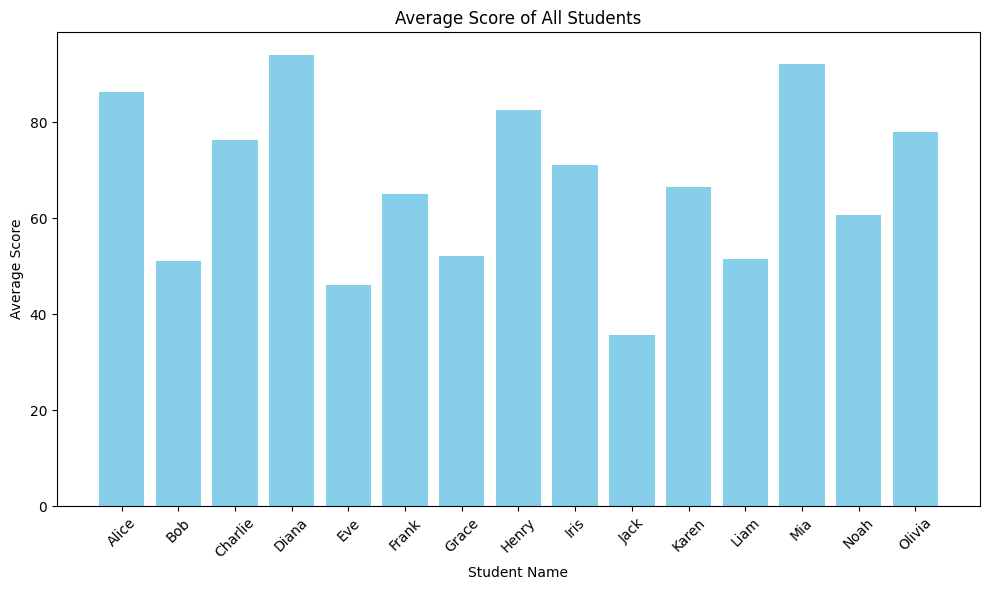


2. plot2_Histogram


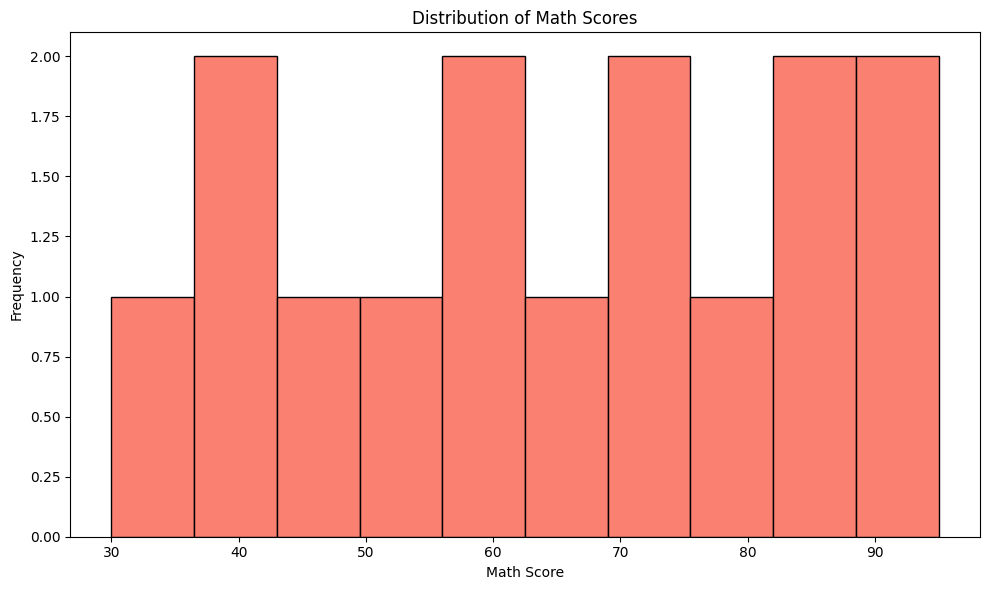


3. plot3_Scatter Plot


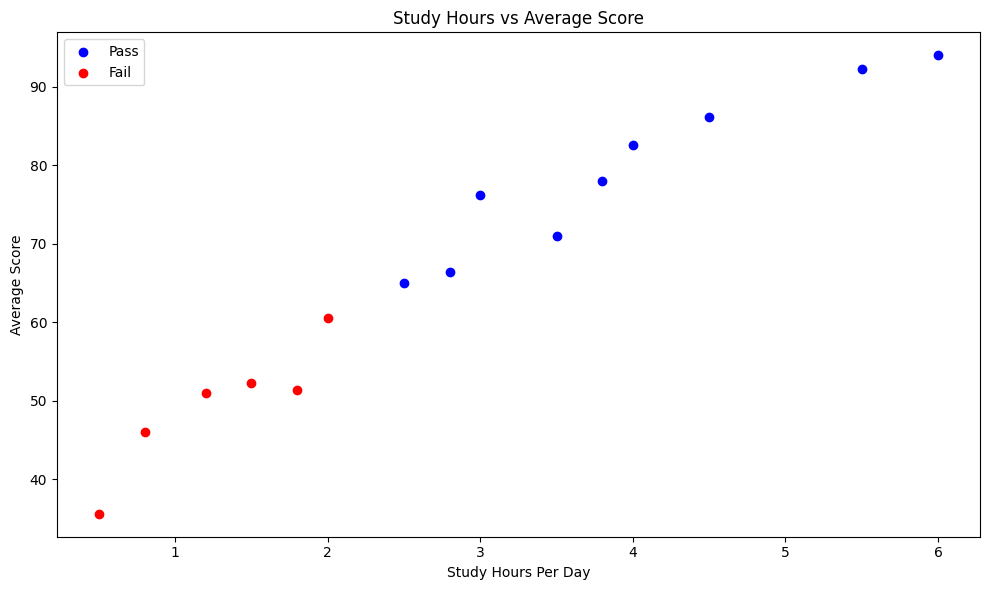


4. plot4_Box Plot


<Figure size 1000x600 with 0 Axes>

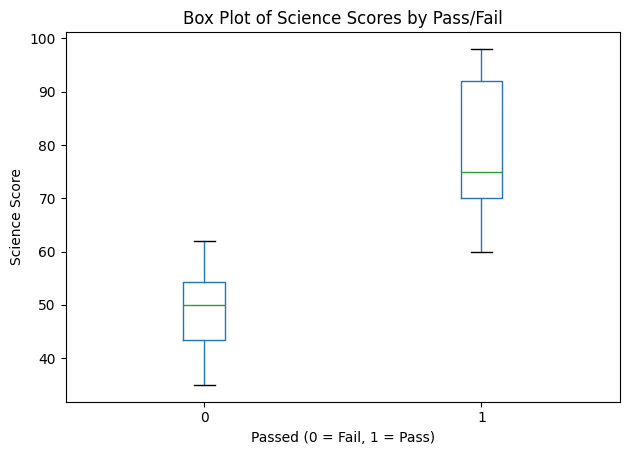


5. plot5_Line Plot


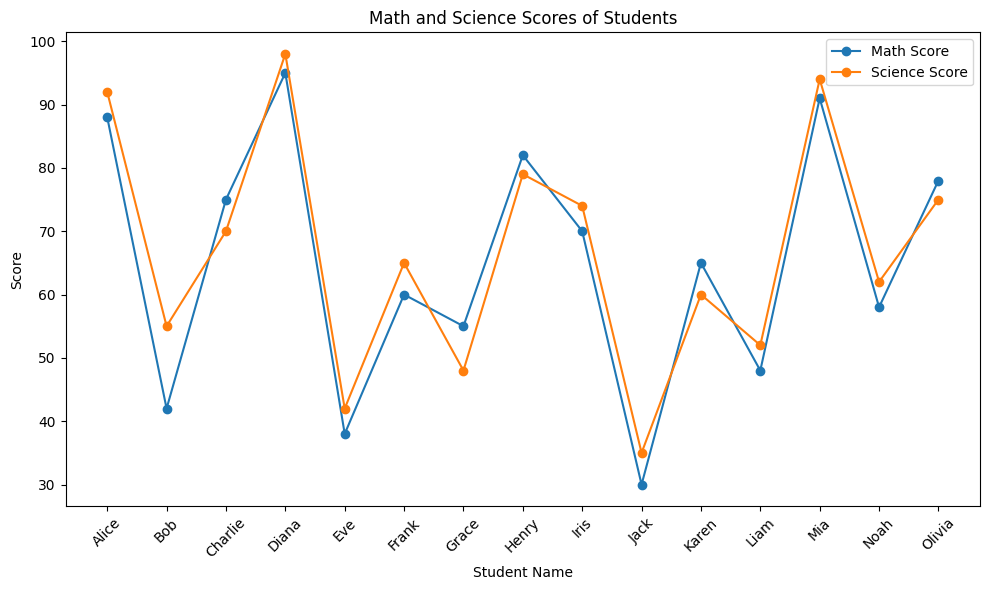


=============Task 2 completed==========.


In [2]:
#Task 2 — Data Visualization with Matplotlib
print("\nTask 2 — Data Visualization with Matplotlib")
#importing the matplotlib library
import matplotlib.pyplot as plt

# Loading the dataset
data = pd.read_csv('students.csv')

#Adding new column to DataFrame as provided in the task description
subject_cols = ['math', 'science', 'english', 'history', 'pe']
data['avg_score'] = data[subject_cols].mean(axis=1)  # type: ignore

#Creating a bar chart to show the average score of all students
print("\n1. plot1_Bar Chart")
plt.figure(figsize=(10, 6))
plt.bar(data['name'], data['avg_score'], color='skyblue')  # type: ignore
plt.xlabel('Student Name')
plt.ylabel('Average Score')
plt.title('Average Score of All Students')
plt.xticks(rotation=45)
plt.savefig("plot1_bar.png")
plt.tight_layout()
plt.show()

#Creating a histogram to show the distribution of scores in math
print("\n2. plot2_Histogram")
plt.figure(figsize=(10, 6))
plt.hist(data['math'], bins=10, color='salmon', edgecolor='black')  # type: ignore
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.title('Distribution of Math Scores')
plt.tight_layout()
plt.savefig("plot2_histogram.png")
plt.show()

#Creating a scatter plot — study_hours_per_day (x-axis) vs avg_score (y-axis)
print("\n3. plot3_Scatter Plot")

plt.figure(figsize=(10, 6))
# Pass
plt.scatter(data[data['passed']==1]['study_hours_per_day'], 
            data[data['passed']==1]['avg_score'], 
            color='blue', label='Pass')

# Fail
plt.scatter(data[data['passed']==0]['study_hours_per_day'], 
            data[data['passed']==0]['avg_score'], 
            color='red', label='Fail')

plt.xlabel('Study Hours Per Day')
plt.ylabel('Average Score')
plt.title('Study Hours vs Average Score')
plt.legend()
plt.tight_layout()
plt.savefig("plot3_scatter.png")
plt.show()

#Creating a box plot to compare the distribution of scores in science for students who passed vs those who failed
print("\n4. plot4_Box Plot")
plt.figure(figsize=(10, 6)) 
data.boxplot(column='science', by='passed', grid=False)  # type: ignore
plt.xlabel('Passed (0 = Fail, 1 = Pass)')
plt.ylabel('Science Score')
plt.title('Box Plot of Science Scores by Pass/Fail')   
plt.suptitle('')  # Suppress the default title
plt.tight_layout()
plt.savefig("plot4_box.png")
plt.show()

#Create Line Plot — Plot the math score and science score for every student. X-axis = student name, Y-axis = score
print("\n5. plot5_Line Plot")
plt.figure(figsize=(10, 6))
plt.plot(data['name'], data['math'], marker='o', label='Math Score')  # type: ignore
plt.plot(data['name'], data['science'], marker='o', label='Science Score')  # type: ignore
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.title('Math and Science Scores of Students')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

print("\n=============Task 2 completed==========.")




Task 3 — Data Visualization with Seaborn

1. plot6_Seaborn Bar Plot


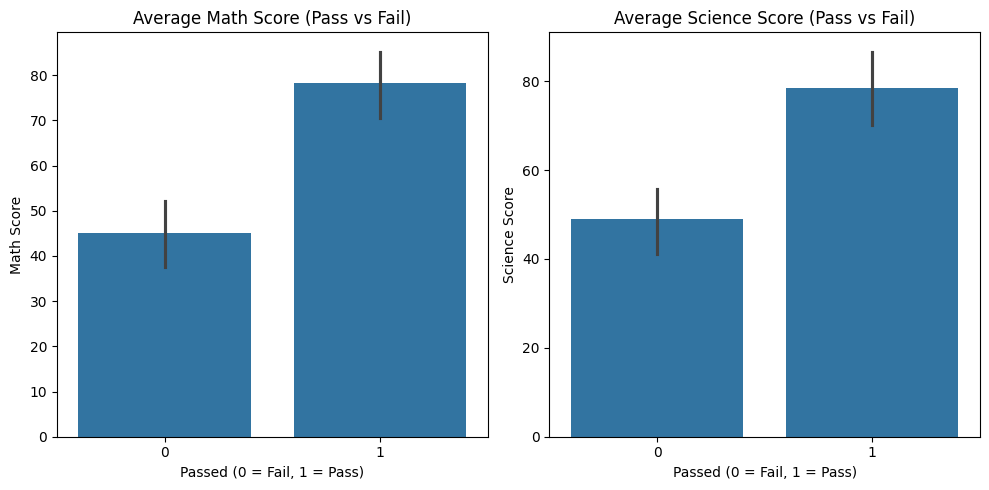


2. plot7_Seaborn Scatter Plot


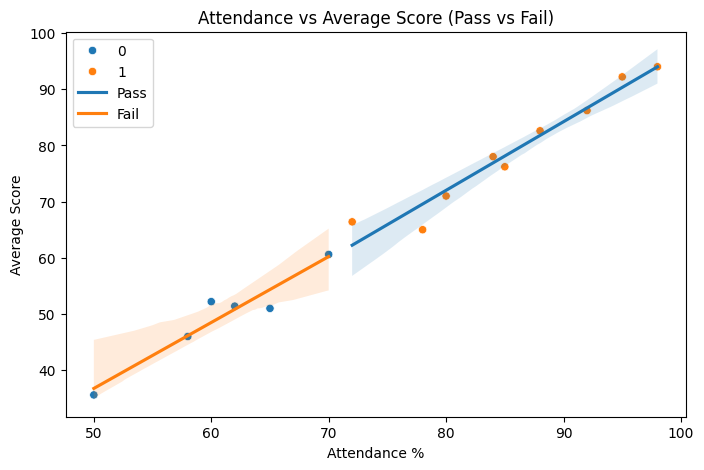


=============Task 3 completed==========.


In [6]:
#Task 3 — Data Visualization with Seaborn
print("\nTask 3 — Data Visualization with Seaborn")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('students.csv')

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

plt.figure(figsize=(10,5))

#creating Seaborn bar plot showing the average math score and average science score, split by passed
print("\n1. plot6_Seaborn Bar Plot")

# Subplot 1: Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=data, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

# Subplot 2: Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=data, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

#creating Seaborn scatter plot of attendance_pct (x-axis) vs avg_score (y-axis), coloured by passed.
print("\n2. plot7_Seaborn Scatter Plot")
plt.figure(figsize=(8,5))

# Scatter plot (colored by passed)
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed') # type: ignore

# Regression line for Pass
sns.regplot(data=df[df['passed']==1], # type: ignore
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

# Regression line for Fail
sns.regplot(data=df[df['passed']==0], # type: ignore
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Comparing Seaborn vs Matplotlib:
# I found Seaborn easier for making nice-looking plots quickly, because it adds colors and styles by default. 
# With Matplotlib, I had to write more code to adjust labels and design, but it gave me more control over every detail.
# Seaborn made the plots look cleaner and more professional with less effort, especially for grouped comparisons like Pass vs Fail.

print("\n=============Task 3 completed==========.")



Task 4 — Machine Learning with Scikit-learn
Training Accuracy: 1.0

Test Accuracy: 1.0

Test Predictions:
Jack: Actual=0, Predicted=0 → Correct
Liam: Actual=0, Predicted=0 → Correct
Alice: Actual=1, Predicted=1 → Correct

Feature Importance (sorted):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


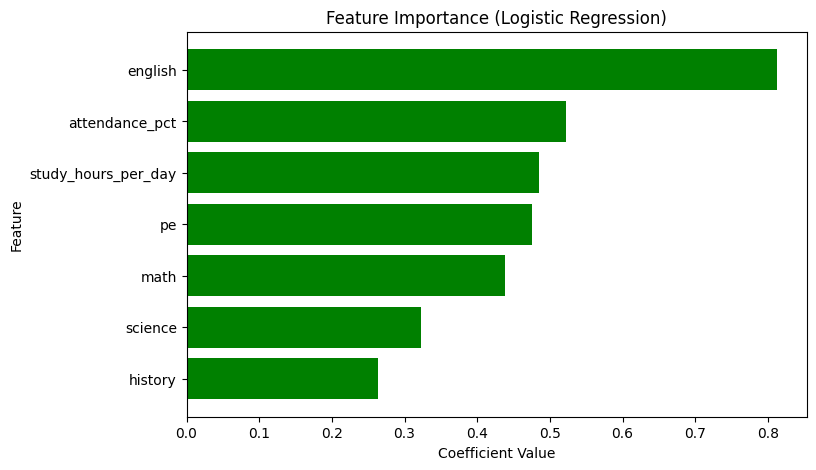


Predicting for a new student:

New Student Prediction: Pass
Probability [Fail, Pass]: [0.09203526 0.90796474]

=============Task 4 completed==========.


c:\Users\ISG\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [11]:
#Task 4 — Machine Learning with Scikit-learn
print("\nTask 4 — Machine Learning with Scikit-learn")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 1 — Prepare data
# Load dataset
df = pd.read_csv('students.csv')

# Features and target
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2 — Train a Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)

# Step 3 — Evaluate the Model
# Predictions
y_pred = model.predict(X_test_scaled)

# Test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", test_acc)

#student wise results
print("\nTest Predictions:")

test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    result = "Correct" if actual == pred else "Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {result}")

#Step 4 - coefficients

coefficients = model.coef_[0]
feature_importance = list(zip(feature_cols, coefficients)) # type: ignore

# Sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")

#Plotting horizontal bar chart using Matplotlib
features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

colors = ['green' if v > 0 else 'red' for v in values]

plt.figure(figsize=(8,5))
plt.barh(features, values, color=colors)
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.savefig("plot8_task 4_horizontal bar chart.png")
plt.show()

#Step 5 — Predict for a New Student 
print("\nPredicting for a new student:")
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scaling it using scaler transform
new_student_scaled = scaler.transform(new_student)

# Prediction
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:", result)
print("Probability [Fail, Pass]:", probability)

print ("\n=============Task 4 completed==========.")